In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db = mysql.connector.connect(host = "localhost",
                             username = "root",
                             password = "Gourav@123",
                             database = "ecommerce_sales")

cur = db.cursor()

# List all unique cities where customers are located.

In [5]:
query = """ SELECT DISTINCT customer_city FROM customers"""

cur.execute(query)

data = cur.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# Count the number of orders placed in 2017.

In [6]:
query = """ SELECT COUNT(order_id) FROM orders WHERE year(order_purchase_timestamp) = 2017"""

cur.execute(query)

data = cur.fetchall()

data[0][0]

45101

# Find the total sales per category.

In [7]:
query = """select products.product_category as category, sum(payments.payment_value) 
from products 
join order_items on products.product_id=order_items.product_id 
join payments on order_items.order_id=payments.order_id group by category;"""

cur.execute(query)

data = cur.fetchall()

data

[('perfumery', 506738.6598940939),
 ('Furniture Decoration', 1430176.3917766158),
 ('telephony', 486882.05071262456),
 ('bed table bath', 1712553.671003269),
 ('automotive', 852294.3311252594),
 ('computer accessories', 1585330.4462582897),
 ('housewares', 1094758.1302838866),
 ('babies', 539845.659735024),
 ('toys', 619037.6894793902),
 ('Furniture office', 646826.4871485233),
 ('Cool Stuff', 779698.0000486821),
 ('HEALTH BEAUTY', 1657373.1193935554),
 ('pet Shop', 311268.9703014195),
 ('General Interest Books', 64694.759615421295),
 ('stationary store', 317440.06965875626),
 ('Watches present', 1429216.6785924584),
 ('PCs', 279121.5493659973),
 ('climatization', 91170.65948677063),
 ('Construction Tools Construction', 241475.6302587986),
 ('sport leisure', 1392127.5591495223),
 ('Bags Accessories', 187151.29038503766),
 ('electronics', 259857.09967413358),
 ('Casa Construcao', 136645.29030653834),
 ('Games consoles', 195480.37912535667),
 ('Fashion Bags and Accessories', 218158.28002

# Calculate the percentage of orders that were paid in installments.

In [11]:
query = """Select (Sum(Case When payment_installments>1 Then 1 Else 0 End) * 100 / Count(*)) from payments"""

cur.execute(query)

data = cur.fetchall()

data[0][0]

Decimal('49.4176')

# Count the number of customers from each state.

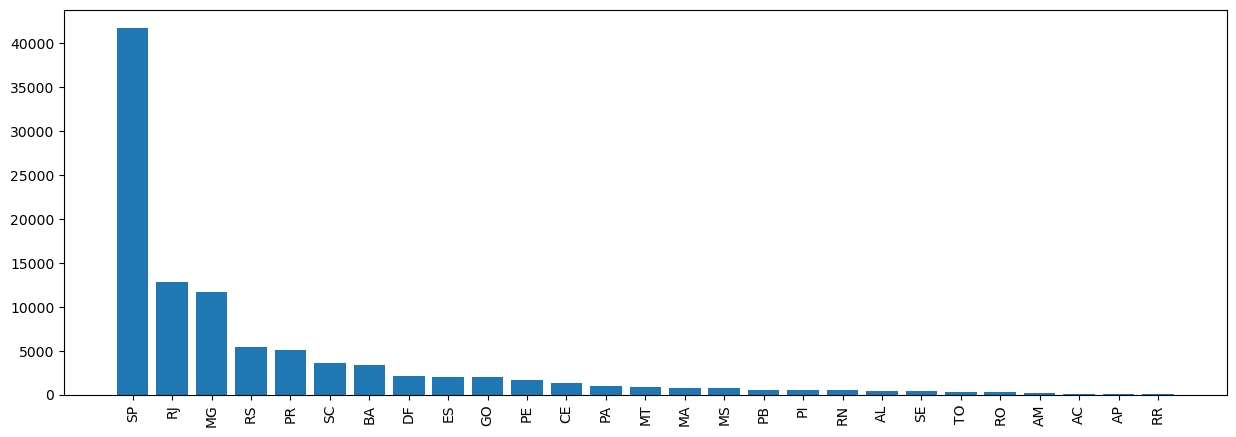

In [22]:
query = """Select customer_state, Count(customer_unique_id) from customers group by customer_state"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["state", "customer_count"])
df = df.sort_values(by = "customer_count", ascending=False)
plt.figure(figsize =(15,5))
plt.bar(df["state"], df["customer_count"])
plt.xticks(rotation = 90)

plt.show()

# Calculate the number of orders per month in 2018.

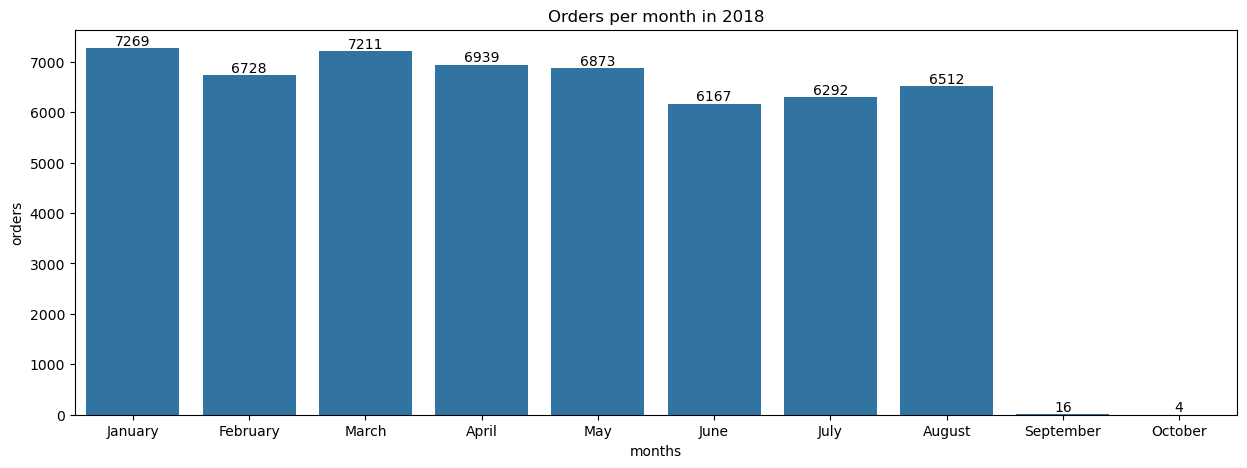

In [33]:
query = """select MONTHNAME(order_purchase_timestamp) AS month, count(order_id) AS orders from ecommerce_sales.orders where year(order_purchase_timestamp)=2018 group by month;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", "orders"])
plt.figure(figsize =(15,5))
# ax = plt.bar(df["months"], df["orders"])
o = ["January", "February","March","April","May","June","July","August","September","October"]
ax = sns.barplot(x= df["months"], y=df["orders"], data=df, order = o)
ax.bar_label(ax.containers[0])
plt.title("Orders per month in 2018")
plt.show()

# Find the average number of products per order, grouped by customer city.

In [39]:
query = """With count_per_order as
(Select orders.order_id, orders.customer_id, Count(order_items.order_id) as oc 
from orders join order_items 
on orders.order_id=order_items.order_id 
group by orders.order_id, orders.customer_id)

select customers.customer_city, CAST(avg(count_per_order.oc) AS DECIMAL(10,2)) as average_orders 
from customers join count_per_order 
on customers.customer_id=count_per_order.customer_id 
group by customers.customer_city order by average_orders desc;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer_city", "avg_products/order"])
df.head(10)

,customer_city,avg_products/order
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
5,morro de sao paulo,4.00
6,teixeira soares,4.00
7,curralinho,4.00
8,cidelandia,4.00
9,picarra,4.00


# Calculate the percentage of total revenue contributed by each product category.

In [4]:
query = """select products.product_category as category, round((sum(payments.payment_value)/(select sum(payments.payment_value) from payments))*100,2) as sales_percentage
from products 
join order_items on products.product_id=order_items.product_id 
join payments on order_items.order_id=payments.order_id group by category order by sales_percentage desc;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1
0,bed table bath,10.70
1,HEALTH BEAUTY,10.35
2,computer accessories,9.90
3,Furniture Decoration,8.93
4,Watches present,8.93
...,...,...
69,House Comfort 2,0.01
70,cds music dvds,0.01
71,PC Gamer,0.01
72,Fashion Children's Clothing,0.00


# Identify the correlation between product price and the number of times a product has been purchased.

In [10]:
query = """SELECT products.product_category, COUNT(order_items.product_id), AVG(order_items.price)
FROM products join order_items on products.product_id=order_items.product_id
GROUP BY products.product_category;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Category", "Order_count", "Price"])

arr1 = df["Order_count"]
arr2 = df["Price"]

a = np.corrcoef([arr1,arr2])
print("The correlation between product price and the number of times a product has been purchased is ", a[0][1])

The correlation between product price and the number of times a product has been purchased is  -0.10631552237549534


# Calculate the total revenue generated by each seller, and rank them by revenue.

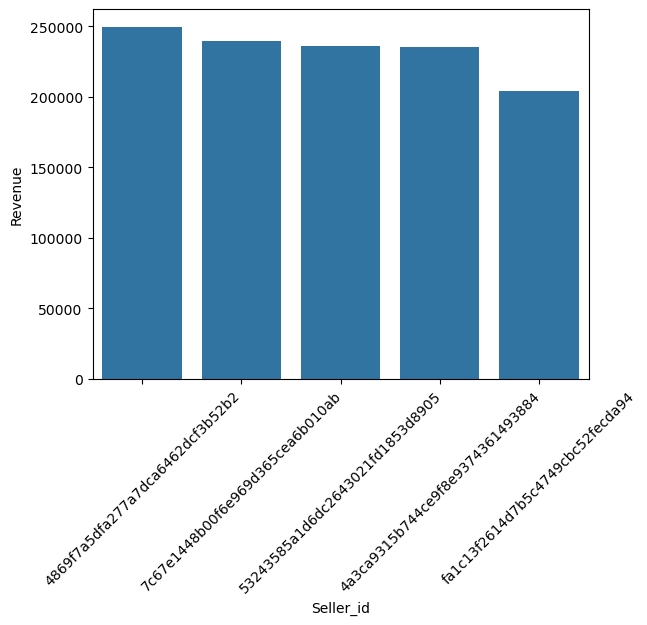

In [7]:
query = """SELECT sellers.seller_id, Round(SUM(order_items.price+order_items.freight_value),2) AS revenue , RANK() OVER (ORDER BY SUM(order_items.price + order_items.freight_value) DESC) AS 'rank'
FROM sellers join order_items on sellers.seller_id=order_items.seller_id
GROUP BY sellers.seller_id;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Seller_id", "Revenue", "Rank"])
df = df.head()
sns.barplot(x="Seller_id", y="Revenue", data=df)
plt.xticks(rotation = 45)
plt.show()

# Calculate the moving average of order values for each customer over their order history.

In [4]:
query = """SELECT customer_id, order_purchase_timestamp,payment,
avg(payment) OVER (partition by customer_id order by order_purchase_timestamp
					ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) as mov_avg
FROM
(select orders.customer_id, orders.order_purchase_timestamp, payments.payment_value as payment
FROM payments join orders on payments.order_id=orders.order_id) as a;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# Calculate the cumulative sales per month for each year.

In [9]:
query = """select years,
	   months, payment,
	   SUM(payment) OVER (
			PARTITION BY years 
            order by months
		) as cumulative_sales 
from (
	SELECT year(orders.order_purchase_timestamp) AS years,
		month(orders.order_purchase_timestamp) AS months,
		round(SUM(payments.payment_value),2) AS payment 
	from payments 
	join orders 
		on payments.order_id=orders.order_id 
	group by years, months
) as a;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,138488.04
4,2017,2,291908.01,430396.05
5,2017,3,449863.60,880259.65
6,2017,4,417788.03,1298047.68
7,2017,5,592918.82,1890966.50
8,2017,6,511276.38,2402242.88
9,2017,7,592382.92,2994625.80


# Calculate the year-over-year growth rate of total sales.

In [12]:
query = """With a as (
SELECT year(orders.order_purchase_timestamp) as years, 
		round(SUM(payments.payment_value),2) as payment
from payments join orders on payments.order_id=orders.order_id
group by years)

select years,
		payment, 
        round(((payment - lag(payment, 1) over(order by years))/lag(payment, 1) over(order by years))*100 ,2) as yoy_growth
from a;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['years', 'payments', 'yoy_%_growth'])
df

,years,payments,yoy_%_growth
0,2016,59362.34,NaN
1,2017,7249746.73,12112.7
2,2018,8699763.05,20.0


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [15]:
query = """With first_purchase AS (
	SELECT 
		customer_id,
		MIN(order_purchase_timestamp) as first_order_date
	FROM orders
	GROUP BY customer_id
),

retained_customers AS (
	SELECT DISTINCT orders.customer_id
    FROM orders
    JOIN first_purchase
		ON orders.customer_id=first_purchase.customer_id
	WHERE
		orders.order_purchase_timestamp > first_purchase.first_order_date
        AND orders.order_purchase_timestamp <= first_purchase.first_order_date + INTERVAL 6 MONTH
)

SELECT 
	COUNT(DISTINCT retained_customers.customer_id) * 100 / COUNT( first_purchase.customer_id) AS retention_rate
FROM first_purchase 
LEFT JOIN retained_customers 
	ON 	first_purchase.customer_id=retained_customers.customer_id;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['retention_rate'])
df

,retention_rate
0,0.0000


# Identify the top 3 customers who spent the most money in each year.

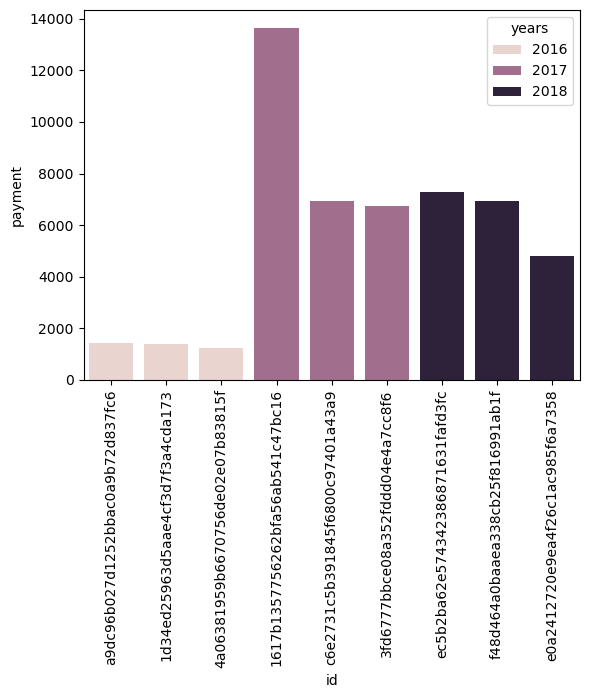

In [18]:
query = """select years, customer_id, payment, d_rank
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments 
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3 ;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years","id","payment","rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()